<a href="https://colab.research.google.com/github/nyfhuv-qimgug-vItby8/-/blob/main/notebook/python-dlshogi2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pythonで将棋AIを作る

## ランタイムのタイプの確認
「ランタイム」－「ランタイムのタイプを変更」から、「ハードウェア アクセラレータ」が「GPU」になっていることを確認します。なっていない場合、「GPU」に変更します。

## CUDAバージョンの確認

In [1]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


## 将棋ライブラリcshogi

### インストール

In [2]:
!pip install cshogi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 26.3 MB/s eta 0:00:00


### パッケージインポート

In [3]:
import cshogi

### 盤面作成

In [4]:
board = cshogi.Board()

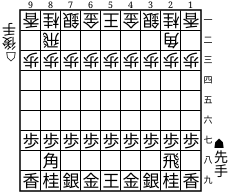

In [5]:
board

### 合法手生成

In [6]:
for move in board.legal_moves:
     print(cshogi.move_to_usi(move))

1g1f
2g2f
3g3f
4g4f
5g5f
6g6f
7g7f
8g8f
9g9f
1i1h
9i9h
3i3h
3i4h
7i6h
7i7h
2h1h
2h3h
2h4h
2h5h
2h6h
2h7h
4i3h
4i4h
4i5h
6i5h
6i6h
6i7h
5i4h
5i5h
5i6h


### 手を指す

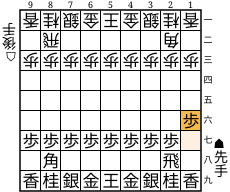

In [7]:
# 合法手生成の1番目の手を指す
move = list(board.legal_moves)[0]
board.push(move)
board

73275


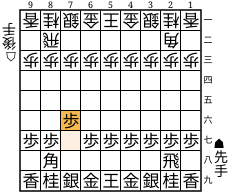

In [8]:
# 指し手にUSIプロトコルの文字列を使う場合
board = cshogi.Board()
move = board.move_from_usi('7g7f')
print(move)
board.push(move)
board

73275


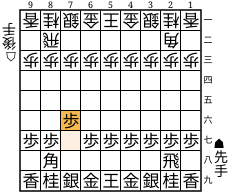

In [9]:
# USIプロトコルの文字列を直接使う
board = cshogi.Board()
move = board.push_usi('7g7f')
print(move)
board

### 手を戻す

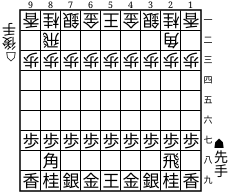

In [10]:
board.pop()
board

## ソースコードとモジュールインストール

In [11]:
# ソースコードのクローン
!git clone https://github.com/TadaoYamaoka/python-dlshogi2.git

Cloning into 'python-dlshogi2'...
remote: Enumerating objects: 217, done.
remote: Counting objects: 100% (63/63), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 217 (delta 57), reused 51 (delta 51), pack-reused 154 (from 2)
Receiving objects: 100% (217/217), 313.81 MiB | 23.90 MiB/s, done.
Resolving deltas: 100% (114/114), done.
Updating files: 100% (23/23), done.


In [12]:
# パッケージインストール
%cd python-dlshogi2
!pip install -e .

/content/python-dlshogi2
Obtaining file:///content/python-dlshogi2
  Preparing metadata (setup.py) ... done
  Running setup.py develop for python-dlshogi2


## モデルの学習

### 訓練データの準備

#### floodgateの棋譜

In [13]:
# ダウンロード
%cd /content
!mkdir floodgate
%cd floodgate
!wget https://wdoor.c.u-tokyo.ac.jp/shogi/archive/wdoor2025.7z

/content
/content/floodgate
--2026-09-09 14:05:42--  https://wdoor.c.u-tokyo.ac.jp/shogi/archive/wdoor2025.7z
Resolving wdoor.c.u-tokyo.ac.jp (wdoor.c.u-tokyo.ac.jp)... 157.82.29.44
Connecting to wdoor.c.u-tokyo.ac.jp (wdoor.c.u-tokyo.ac.jp)|157.82.29.44|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 351630898 (335M) [application/x-7z-compressed]
Saving to: ‘wdoor2025.7z’

wdoor2025.7z        100%[===================>] 335.34M  20.7MB/s    in 17s     

2026-09-09 14:06:00 (19.7 MB/s) - ‘wdoor2025.7z’ saved [351630898/351630898]



In [14]:
# 2025年1月分を解凍
!7z x wdoor2025.7z "2025/*202501*.csa"


7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,2 CPUs Intel(R) Xeon(R) CPU @ 2.20GHz (406F0),ASM,AES-NI)

Scanning the drive for archives:
  0M Scan         1 file, 351630898 bytes (336 MiB)

Extracting archive: wdoor2025.7z
--
Path = wdoor2025.7z
Type = 7z
Physical Size = 351630898
Headers Size = 1956862
Method = LZMA2:24
Solid = +
Blocks = 1

  0%      0% 365 . 2025/wdoor+floodgate-300-10F+36 . 03+nn14_N150+20250906090001.csa                                                                              1% 1139 . 2025/wdoor+floodgate-300-10F+910+478_test4+20251223023004.csa                                                                         

2月分から12月分も同様に解凍します。解凍には時間がかかるため、時間がない場合は、2月分から12月分の解凍を省略して1月分のデータのみで「CSA形式の棋譜からhcpe形式に変換」以降の手順を試すことができます。

In [15]:
# 2025年2月分を解凍
!7z -aoa x wdoor2025.7z "2025/*202502*.csa"


7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,2 CPUs Intel(R) Xeon(R) CPU @ 2.20GHz (406F0),ASM,AES-NI)

Scanning the drive for archives:
  0M Scan         1 file, 351630898 bytes (336 MiB)

Extracting archive: wdoor2025.7z
--
Path = wdoor2025.7z
Type = 7z
Physical Size = 351630898
Headers Size = 1956862
Method = LZMA2:24
Solid = +
Blocks = 1

  0%      0% 32 - 2025/wdoor+floodgate-300-10F+20 . 000+gikou2_1c+20250225043010.csa                                                                              0% 69 - 2025/wdoor+floodgate-300-10F+202502264201+i3_4160t+20250226223011.csa                                                                 

In [16]:
# 2025年3月分を解凍
!7z -aoa x wdoor2025.7z "2025/*202503*.csa"


7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,2 CPUs Intel(R) Xeon(R) CPU @ 2.20GHz (406F0),ASM,AES-NI)

Scanning the drive for archives:
  0M Scan         1 file, 351630898 bytes (336 MiB)

Extracting archive: wdoor2025.7z
--
Path = wdoor2025.7z
Type = 7z
Physical Size = 351630898
Headers Size = 1956862
Method = LZMA2:24
Solid = +
Blocks = 1

  0%      0% 79 - 2025/wdoor+floodgate-300-10F+20 . _473stb_1000k+20250301133004.csa                                                                              0% 91 - 2025/wdoor+floodgate-300-10F+20250305+John+20250305163004.csa                                                                       

In [ ]:
# 2025年4月分を解凍
!7z -aoa x wdoor2025.7z "2025/*202504*.csa"


7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,2 CPUs Intel(R) Xeon(R) CPU @ 2.20GHz (406F0),ASM,AES-NI)

Scanning the drive for archives:
  0M Scan         1 file, 351630898 bytes (336 MiB)

Extracting archive: wdoor2025.7z
--
Path = wdoor2025.7z
Type = 7z
Physical Size = 351630898
Headers Size = 1956862
Method = LZMA2:24
Solid = +
Blocks = 1

  0%      0% 158 - 2025/wdoor+floodgate-300-10F+ . 1_avg_3200p+20250402120008.csa                                                                           0% 170 - 2025/wdoor+floodgate-300-10F+ . kun_depth8+20250402063007.csa                                                                        

In [ ]:
# 2025年5月分を解凍
!7z -aoa x wdoor2025.7z "2025/*202505*.csa"

In [ ]:
# 2025年6月分を解凍
!7z -aoa x wdoor2025.7z "2025/*202506*.csa"

In [ ]:
# 2025年7月分を解凍
!7z -aoa x wdoor2025.7z "2025/*202507*.csa"

In [ ]:
# 2025年8月分を解凍
!7z -aoa x wdoor2025.7z "2025/*202508*.csa"

In [ ]:
# 2025年9月分を解凍
!7z -aoa x wdoor2025.7z "2025/*202509*.csa"

In [ ]:
# 2025年10月分を解凍
!7z -aoa x wdoor2025.7z "2025/*202510*.csa"

In [ ]:
# 2025年11月分を解凍
!7z -aoa x wdoor2025.7z "2025/*202511*.csa"

In [ ]:
# 2025年12月分を解凍
!7z -aoa x wdoor2025.7z "2025/*202512*.csa"

#### CSA形式の棋譜からhcpe形式に変換

In [ ]:
%cd /content/python-dlshogi2
!python utils/csa_to_hcpe.py /content/floodgate train.hcpe test.hcpe

### 訓練の実行

変換した訓練データとテストデータを使用して、モデルを訓練します。1月分から12月分をすべて解凍した場合は、実行に時間がかかるため、定期的にPCを操作してセッションタイムアウトが発生しないようにしてください。

In [ ]:
!python pydlshogi2/train.py train.hcpe test.hcpe

In [ ]:
# チェックポイントが保存されていることを確認
!ls -l checkpoints

#### チェックポイントをローカルにダウンロード

In [ ]:
# zipで圧縮
!zip checkpoint-001.zip checkpoints/checkpoint-001.pth

左のファイルタブから、python-dlshogi2/checkpoint-001.zipを右クリックしてダウンロードを選択します。

## 対局プログラムの実装

### テスト

In [ ]:
# ディレクトリ移動
%cd /content/python-dlshogi2

In [ ]:
# 作成済みのmcts_player.shの内容表示
!cat mcts_player.sh

In [ ]:
# 実行権を付与
!chmod +x mcts_player.sh

In [ ]:
# 実行
!./mcts_player.sh

## Colabで対局

In [ ]:
# パッケージをインポート
import cshogi.web.app

### 人間プレイヤーとの対局

In [ ]:
# 人間プレイヤーと対局
cshogi.web.app.colab(
    engine1='human',
    engine2='./mcts_player.sh',
    options2={'modelfile': 'checkpoints/checkpoint-001.pth'},
    byoyomi=1000)

### USIエンジンとの対局

In [ ]:
# Lesserkaiのソースをダウンロードしてビルド
%cd /content/
!wget http://shogidokoro.starfree.jp/download/LesserkaiSrc.zip
!unzip LesserkaiSrc.zip
%cd LesserkaiSrc/Lesserkai
!make

In [ ]:
# ディレクトリを元の場所に移動
%cd /content/python-dlshogi2

In [ ]:
# Lesserkaiと対局
cshogi.web.app.colab(
    engine1='./mcts_player.sh',
    engine2='/content/LesserkaiSrc/Lesserkai/Lesserkai',
    options1={'modelfile': 'checkpoints/checkpoint-001.pth'},
    byoyomi=1000)

### dlshogiのモデルと対局

In [ ]:
# onnxruntimeをインストール
!pip install onnxruntime-gpu

In [ ]:
# 作成済みのonnx_player.shの内容表示
!cat onnx_player.sh

In [ ]:
# 実行権を付与
!chmod +x onnx_player.sh

In [ ]:
# GCT電竜のモデルと対局
cshogi.web.app.colab(
    engine1='./mcts_player.sh',
    engine2='./onnx_player.sh',
    options1={'modelfile': 'checkpoints/checkpoint-001.pth'},
    options2={'modelfile': 'model/model-0000167.onnx'},
    byoyomi=1000)